# **Project 2: Implementing Simple Linear Regression with Ordinary Least Squares (OLS) and Sum of Squared Errors (SSE) equations**

## **Objective**
In this assignment, you will implement simple linear regression from scratch using only NumPy and base Python. You will:

- Express linear regression in **matrix notation**.
- Compute the **line of best fit** using **OLS**.
- Calculate the **sum of squared errors (SSE)** to evaluate the model.

By the end of this assignment, you will understand how to derive and implement **linear regression** in its fundamental mathematical form.

---

## **Background**

### **Linear Regression Equation**
Simple linear regression is expressed as:


\begin{equation}
y = mx + b
\end{equation}


where:
- \( y \) is the **dependent variable** (target),
- \( x \) is the **independent variable** (feature),
- \( m \) is the **slope** (coefficient),
- \( b \) is the **y-intercept**.

---

### **Matrix Form**
We can express the equation in **matrix notation**:

\begin{equation}
Y = X \beta
\end{equation}

where:
- \$ Y \$ is an \$ n \times 1 \$ vector of observed values:

  \begin{aligned}
  Y =
  \begin{bmatrix}
  y_1 \\
  y_2 \\
  \vdots \\
  y_n
  \end{bmatrix}
  \end{aligned}

- \$ X \$ is an \$ n \times 2 \$ **design matrix**, where the first column consists of ones (for the intercept) and the second column contains the \$ x \$ values:

  \begin{aligned}
  X =
  \begin{bmatrix}
  1 & x_1 \\
  1 & x_2 \\
  \vdots & \vdots \\
  1 & x_n
  \end{bmatrix}
  \end{aligned}

- \$ \beta \$ is a \$ 2 \times 1 \$ vector containing the intercept \$( b \$) and slope \$( m \$):

  \begin{aligned}
  \beta =
  \begin{bmatrix}
  b \\
  m
  \end{bmatrix}
  \end{aligned}

Thus, our model can be rewritten as:

\begin{aligned}
\begin{bmatrix}
y_1 \\
y_2 \\
\vdots \\
y_n
\end{bmatrix}
&=
\begin{bmatrix}
1 & x_1 \\
1 & x_2 \\
\vdots & \vdots \\
1 & x_n
\end{bmatrix}
\begin{bmatrix}
b \\
m
\end{bmatrix}
\end{aligned}

---

### **Computing the Best Fit Line Using the ordinary least squares (OLS)**
The **best fit line** is obtained using the **ordinary least squares (OLS)**:

\begin{equation}
\beta = (X^T X)^{-1} X^T Y
\end{equation}

where:
- \$ X^T \$ is the transpose of \$ X \$,
- \$ (X^T X)^{-1} \$ is the **inverse** of \$ X^T X \$,
- \$ X^T Y \$ is the product of the transposed \$ X \$ and \$ Y \$.
---

### **Sum of Squared Errors (SSE)**
The **sum of squared errors (SSE)** is used to measure how well the regression line fits the data:


\begin{equation}
SSE = \frac{1}{n}\sum_{i=1}^{n} \|y_i - \hat{y}_i\|^2
\end{equation}

where:
- \$ y_i \$ represents the actual observed values,
- \$ \hat{y}_i \$ are the predicted values from the model.

Alternatively, using matrix notation:

\begin{equation}
SSE = (Y - X \beta)^T (Y - X \beta)
\end{equation}

where \$ Y - X\beta \$ represents the **residuals** (differences between actual and predicted values).

---

### **Coding**


###1. Import Required Libraries
For this lab only use NumPy, Pandas, Matplotlib, and base Python.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

###2. Data

* We have a data set that describes 506 suburbs in Boston. Find the documentation for the variables [here](https://islp.readthedocs.io/en/latest/datasets/Boston.html).
* *Goal*: Predict the median value (in $1000s) of houses owned in that suburb.
* *Task*: Use the covariates / indepednent variables from the data set to create 3 different types of predictive models: single variable, multivariable, and polynomial regression.

**First step: import the data, split into x and y, and turn them into numpy arrays.**

In [3]:
#https://islp.readthedocs.io/en/latest/datasets/Boston.html
df = pd.read_csv('https://raw.githubusercontent.com/intro-stat-learning/ISLP/refs/heads/main/ISLP/data/Boston.csv')
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [4]:
# remove the last column because we cannot use the dependent variable in the model
x = df.iloc[:, :-1]
x.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33


**Begin with a single variable model, selecting the 6th column: 'rm' (average number of rooms per dwelling)**

In [ ]:
# Starting with single linear regression
x = df.iloc[:, 5:6].to_numpy() # conv to numpy array (single variable model)
print(x[:5]) # taking a look

[[6.575]
 [6.421]
 [7.185]
 [6.998]
 [7.147]]


**Select the target variable that we want to predict: medv (median value of owner-occupied homes in $1000s)**

In [ ]:
y = df.iloc[:, -1:].to_numpy() # conv to numpy array
print(y[:5]) # taking a look


[[24. ]
 [21.6]
 [34.7]
 [33.4]
 [36.2]]


**Turn both data frame objects into numpy arrays.**

In [ ]:
# x = x.to_numpy() already done

In [ ]:
# y = y.to_numpy() # already done

### 3. Prepare Data in Matrix Form

#### 3a. Convert 𝑥 into matrix form by adding a column of ones for the intercept.

In [12]:
def prepare_matrix(x):
    n = len(x)
    X = np.column_stack((np.ones(n), x))  # shape (n, 2)
    return X

X = prepare_matrix(x)
Y = y.reshape(-1, 1)  # reshape y to column vector (aka nx1 matrix)

#### 3b. Standardize the data. **(2 points)**

In [13]:
# insert your code for standardizing the data
# **remember that currently, your x variable is just the rm column, when you do question 7 and after, make sure every non-label column you use is also standardized**
means = np.mean(x, axis=0)
stds = np.std(x, axis=0)
x_standardized = (x - means) / stds

print(x_standardized)

[[ 4.13671889e-01]
 [ 1.94274453e-01]
 [ 1.28271368e+00]
 [ 1.01630251e+00]
 [ 1.22857665e+00]
 [ 2.07096381e-01]
 [-3.88410945e-01]
 [-1.60465557e-01]
 [-9.31205901e-01]
 [-3.99808215e-01]
 [ 1.31589471e-01]
 [-3.92684921e-01]
 [-5.63643963e-01]
 [-4.78164442e-01]
 [-2.68739617e-01]
 [-6.42000190e-01]
 [-4.98109663e-01]
 [-4.19753436e-01]
 [-1.18052117e+00]
 [-7.94438668e-01]
 [-1.01811008e+00]
 [-4.55369903e-01]
 [-2.03205317e-01]
 [-6.71918022e-01]
 [-5.13780909e-01]
 [-9.76794979e-01]
 [-6.71918022e-01]
 [-3.38547892e-01]
 [ 2.99699195e-01]
 [ 5.54713098e-01]
 [-8.14383890e-01]
 [-3.02931425e-01]
 [-4.76739783e-01]
 [-8.31479794e-01]
 [-2.68739617e-01]
 [-5.00958981e-01]
 [-6.32027579e-01]
 [-6.19205651e-01]
 [-4.53945244e-01]
 [ 4.42165063e-01]
 [ 1.05334363e+00]
 [ 6.91480331e-01]
 [-1.64739533e-01]
 [-1.04903869e-01]
 [-3.07205401e-01]
 [-8.58548308e-01]
 [-7.10383806e-01]
 [-3.62767089e-01]
 [-1.26172671e+00]
 [-9.72521003e-01]
 [-4.58219220e-01]
 [-2.41671102e-01]
 [ 3.2249373

#### 3c. *Why do we add a column of ones to the 𝑋 matrix?*  **(2 points)**

We include a first column of 1’s to the X matrix to represent the intercept term in the linear regression model. The "1" acts as a multiplier for $\beta_0$, ensuring the intercept is added to every single prediction. If the ones were not there, the model would be forced to pass through the origin, which would hurt our accuracy. We want to be able to assign the model a y-intercept, which the column of ones allows us to do. 

#### 3d. *Why do we need to standardize our data for linear regression?*  **(2 points)**

We need to standardize our data for linear regression because it allows for direct comparison of predictor importance when using multiple features. Standardizing our data puts all features in the same unit/scale. For example, if one feature is in kilometers, but another is in millimeters, the coefficient for the one in millimeters will be 1,000,000x smaller than the one for kilometers, even if they have the exact same impact on the target variable. When standardized, the coefficient ($\beta$) represents the change in the target variable for a 1 standard deviation change in input. This allows us to compare the magnitude of the coefficients directly to see which features have the strongest effect on the prediction. Additionally, when computing the Normal Equation, if some features have very high magnitudes, the numbers in your matrix will span a massive range of magnitudes. By standardizing, we can ensure all the numbers in the $X^T X$ matrix have a similar magnitude, making the inversion process much more seamless.

#### 3e. *Why do we only standardize the 𝑋 matrix?* **(2 points)**

We only standardize the X matrix (the features) because our goal is to stabilize the relationship between variables, not to change the final output of the target variable. If we're predicting median values of houses, we want our output to be a numerical dollar value, not a standardized Z-score like those computed in the X matrix. 

### 4. Compute the Best Fit Line Using OLS
#### 4a. Use the formula for Ordinary Least Squares (OLS) Regression to compute the $\beta$ vector. (Hint: Review Lab 4) **(2 points)**

In [ ]:
# Compute beta vector
n = len(x_standardized)
X = np.column_stack([np.ones(n), x_standardized])

betas = np.linalg.inv(X.T @ X) @ X.T @ y # using same formula from the lab

print(betas)

[[22.53280632]
 [ 6.38897522]]


#### 4b. *Explain how OLS finds the line of best fit.* **(2 points)**

OLS finds the line of best fit by finding the specific line where the total error (residuals) between the data points and the line is as small as possible. The residuals are vertical distances between the  observed value ($y$) and the value predicted by the line ($\hat{y}$). OLS squares the residuals (so they're always positive and to penalize outliers). Finally, it uses calculus (derivatives) to directly compute the coefficients that minimize SSE for every possible line that could be drawn through the data, selecting the best fit line with the lowest SSE. To do this it uses the normal equation, $$\hat{\beta} = (X^T X)^{-1} X^T y$$

### 5. Using your computed values for $\beta$, generate the predicted values for the training data.
#### 5a. Use the computed $\beta$ to find the predictions $\hat{Y}$ using matrix multiplication with the design matrix X. **(2 points)**

In [17]:
# Create variable Y_pred (a list of predictions for each suburb)
def predict(X, beta):
    return X @ beta

Y_pred = predict(X, betas)
Y_pred

array([[25.17574577],
       [23.77402099],
       [30.72803225],
       [29.02593787],
       [30.38215211],
       [23.85593997],
       [20.05125842],
       [21.50759586],
       [16.5833549 ],
       [19.97844155],
       [23.3735282 ],
       [20.02395209],
       [18.93169901],
       [19.47782555],
       [20.81583557],
       [18.43108302],
       [19.35039603],
       [19.85101202],
       [14.99048582],
       [17.45715736],
       [16.02812625],
       [19.6234593 ],
       [21.23453259],
       [18.23993873],
       [19.25027283],
       [16.29208741],
       [18.23993873],
       [20.36983223],
       [24.44757706],
       [26.07685456],
       [17.32972783],
       [20.59738496],
       [19.48692766],
       [17.22050253],
       [20.81583557],
       [19.33219181],
       [18.49479778],
       [18.57671676],
       [19.63256141],
       [25.35778795],
       [29.26259271],
       [26.95065703],
       [21.48028953],
       [21.86257811],
       [20.57007863],
       [17

#### *5b. What does the y_pred array respresent?* **(2 points)**

The Y_pred array represents a numpy array (outputted list) of the model's predicted median house values (in 1000s of dollars) for each of the observations. Mathematically, it represents the $y$-coordinates of the regression line for every given $x$ value in the data.

### 6. Calculate the normalized Sum of Squared Errors (SSE) for the model.
#### 6a. Compute the SSE to measure how well the regression model fits the training data. **(2 points)**

> **Important:** In this assignment, whenever we say “SSE,” we mean the **normalized** version:

$ \text{SSE} = \frac{1}{n}\sum_{i=1}^{n}(y_i-\hat y_i)^2$

> where \(n\) is the number of samples used in that SSE calculation (train or test). This makes train/test errors comparable even when the split sizes differ.


In [19]:
# Compute the **normalized** SSE (SSE/n) and store it in the variable `sse`.
# SSE = (1/n) * sum_i (y_i - yhat_i)^2, where n = number of samples used in this SSE.

sse = (1/n) * np.sum((y - Y_pred)**2) # used the given formula
print(sse)


43.60055177116956


#### *6b. How does SSE relate to the goodness of fit of the model? In other words, what do we want SSE to be?* **(2 points)**

SSE relates to the goodness of fit of the model because the lower the SSE, the better the model. This is because SSE is a measure of the error, so we want SSE to be as small as possible (close to 0) to indicate our error is as low as possible. A lower SSE means that the predictions are closer to the actual data points, indicating a better fitting model.

### 7. Visualize the resulting regression model and line of best fit. Plot the data alongside the line of best fit.

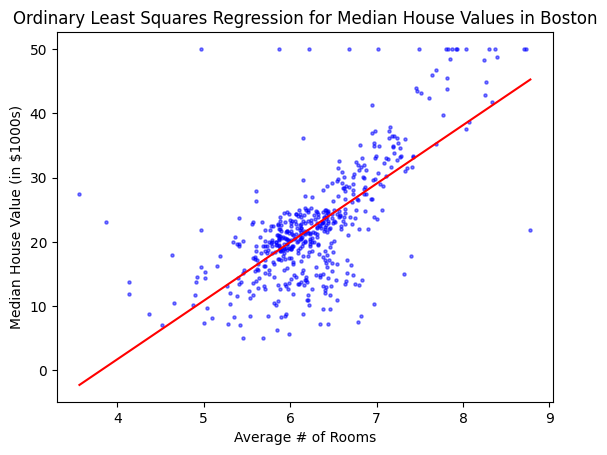

In [20]:
X_vals = np.linspace(x_standardized.min(), x_standardized.max(), num=1000)
plt.scatter(x, y, s=5, c='b', alpha=0.5)
plt.plot((X_vals * np.std(x)) + np.mean(x), betas[0] + betas[1] * X_vals, 'r')
plt.ylabel('Median House Value (in $1000s)')
plt.xlabel('Average # of Rooms')
plt.title('Ordinary Least Squares Regression for Median House Values in Boston')
plt.show()

### 8. The above plot looks at the relationship between *rm* (an independent variable) and *mdev* (the dependent variable we are trying to predict). Create a single ordinary least squares (OLS) regression with a different independent variable (other than *rm*) from our data set. Once you have your predictions, plot the line of best fit with your chosen independent variable on the x-axis and *mdev* on the y-axis. **(2 points)**

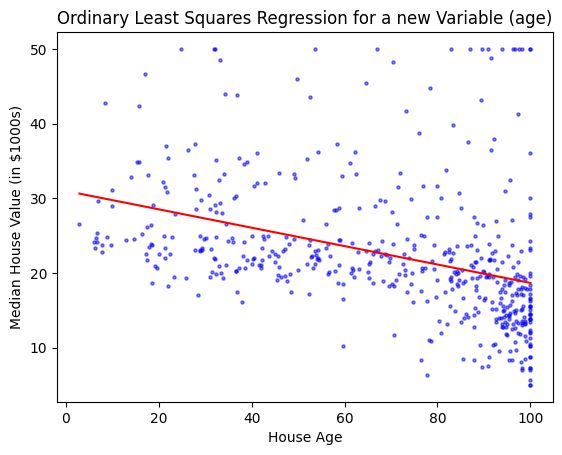

In [ ]:
### implement your single regression model here

x2 = df.iloc[:, 6:7].to_numpy() # age column

means2 = np.mean(x2, axis=0)
stds2 = np.std(x2, axis=0)
x_standardized2 = (x2 - means2) / stds2

n2 = len(x2)
X2 = np.column_stack([np.ones(n2), x_standardized2])

betas2 = np.linalg.lstsq(X2, y, rcond=None)[0]

Y_pred2 = predict(X2, betas2)

X_vals2 = np.linspace(x_standardized2.min(), x_standardized2.max(), num=1000)

plt.scatter(x2, y, s=5, c='b', alpha=0.5)
plt.plot((X_vals2 * np.std(x2)) + np.mean(x2), betas2[0] + betas2[1] * X_vals2, 'r')

plt.ylabel('Median House Value (in $1000s)')
plt.xlabel('House Age')
plt.title('Ordinary Least Squares Regression for a new Variable (age)')
plt.show()

### 9.
To this point, you've trained a single variable linear regression on just the training data. This tells us how the model will perform on data we already have, but not on actual data we recieve in the future. To get a better understanding of how the data will run on unseen data, we need to split our data into training and testing data.


Now, train a single linear regression model using a train/test split. Identify how the model does on the training vs testing data.

#### 9a. Split the data into a training and test split. In the training set, keep 80% of the observations. In the test set, keep the other 20% of observations. **(2 points)**

In [96]:
x_age = df.iloc[:, 6:7].to_numpy()

# split into training and testing sets (80/20)
np.random.seed(1000)
indices = np.random.permutation(len(x_age))
train_size = int(0.8 * len(x_age))
train_idx, test_idx = indices[:train_size], indices[train_size:]
x_train, x_test = x_age[train_idx], x_age[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# standardizing the data...
age_mean = x_train.mean(axis=0)
age_std = x_train.std(axis=0)

x_train_scaled_age = (x_train - age_mean) / age_std
x_test_scaled_age = (x_test - age_mean) / age_std  # scale based on training data

X_train_scaled = prepare_matrix(x_train_scaled_age)
X_test_scaled = prepare_matrix(x_test_scaled_age)

#### 9b. With your training data, train the model by minimizing the Sum of Squared Errors (normalized SSE (SSE/n)). You will have one coefficient for the intercept term $(\beta_0)$ and another for your chosen independent variable ($\beta_1$). **(10 points)**

> Reminder: use **SSE = (1/n)·∑(y-ŷ)^2** with n equal to the sample size for that split.


In [97]:
age_index = df.columns.get_loc('age')
print(age_index)

6


In [98]:
# Train model by minimizing the (normalized) SSE.
# Note: dividing SSE by n does NOT change the optimal coefficients (it only rescales the objective).
# TODO: implement training below

# chosen IV was age (as used before)

X_train = np.column_stack([np.ones(len(x_train_scaled_age)), x_train_scaled_age])

# flatten y for matrix math
y_train_flat = y_train.flatten()

# closed form OLS solution (minimize that SSE)
beta_hat = np.linalg.inv(X_train.T @ X_train) @ X_train.T @ y_train_flat

# pull the coefficents
beta_0 = beta_hat[0]   # intercept
beta_1 = beta_hat[1]   # coeff for age

print("beta_0 (intercept):", beta_0)
print("beta_1 (age coefficient):", beta_1)

# predictions on training data
yhat_train = X_train @ beta_hat

# normed sse
n = len(y_train_flat)
sse_train = (1/n) * np.sum((y_train_flat - yhat_train)**2)

print("normalized sse (train):", sse_train)


beta_0 (intercept): 22.26014851485148
beta_1 (age coefficient): -3.4052752474512973
normalized sse (train): 67.39600244723687


#### 9c. Using your trained model ($\beta$ coefficients), calculate your predictions on the training data set. Compare your predictions with the true values of *mdev* in the train set by computing the normalized SSE (SSE/n). Report your value of normalized SSE (SSE/n). **(5 points)**

> Reminder: use **SSE = (1/n)·∑(y-ŷ)^2** with n equal to the sample size for that split.


In [99]:
# Evaluate your trained model on the training data.
# Compute the **normalized** SSE (SSE/n) on the TRAIN split.
# TODO: compute sse_train below

# design matrix for training data (intercept and age)
X_train = np.column_stack([np.ones(len(x_train_scaled_age)), x_train_scaled_age])

yhat_train = X_train @ beta_hat
y_train_flat = y_train.flatten()

# normalized sse
n = len(y_train_flat)
sse_train = (1/n) * np.sum((y_train_flat - yhat_train)**2)

print("Normalized SSE (train)=", sse_train)


Normalized SSE (train)= 67.39600244723687


#### 9d. Now use your trained model to calculate your predictions on the test data set. Compute the normalized SSE (SSE/n) on the test data set. **(5 points)**

> Reminder: use **SSE = (1/n)·∑(y-ŷ)^2** with n equal to the sample size for that split.


In [100]:
# Evaluate your trained model on the test data.
# Compute the **normalized** SSE (SSE/n) on the TEST split.
# TODO: compute sse_test below


X_test = np.column_stack([np.ones(len(x_test_scaled_age)), x_test_scaled_age])

yhat_test = X_test @ beta_hat
y_test_flat = y_test.flatten()
n = len(y_test_flat)
sse_test = (1/n) * np.sum((y_test_flat - yhat_test)**2)

print("Normalized SSE (test)=", sse_test)


Normalized SSE (test)= 92.68047697889949


#### 9e. How does the SSE on the test set compare to the SSE on the training set? **(2 points)**

**Answer:**

The SSE on the train set is smaller than the one on the train set. This is because the model was trained on the training set and it expected to do better on the training set than on the test set. However, the two being very close together is a good indicator that the model is not overfitting, and may be generalizing well. 


### 9f. Plot (like in Question 7) your line of best fit over your training data. **(2 points)**

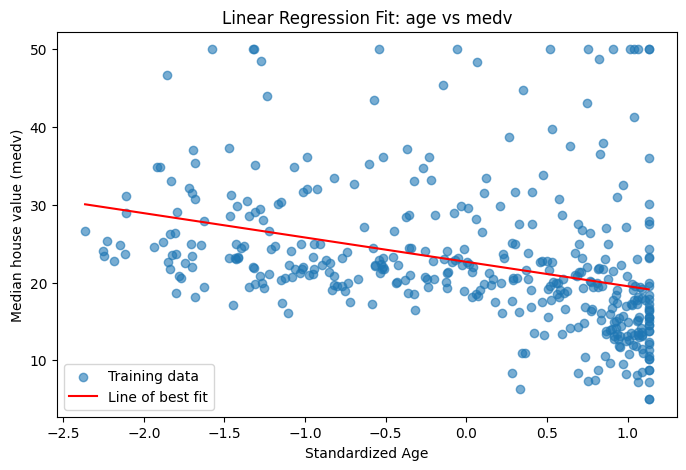

In [74]:

x_feature = x_train_scaled_age.flatten()
y_true = y_train.flatten()
x_sorted = np.sort(x_feature)
y_line = beta_0 + beta_1 * x_sorted

plt.figure(figsize=(8,5))
plt.scatter(x_feature, y_true, alpha=0.6, label="Training data")
plt.plot(x_sorted, y_line, color="red", label="Line of best fit")

plt.xlabel("Standardized Age")
plt.ylabel("Median house value (medv)")
plt.title("Linear Regression Fit: age vs medv")
plt.legend()
plt.show()

### 9g. Plot (like in Question 7) your line of best fit over your test data. **(2 points)**

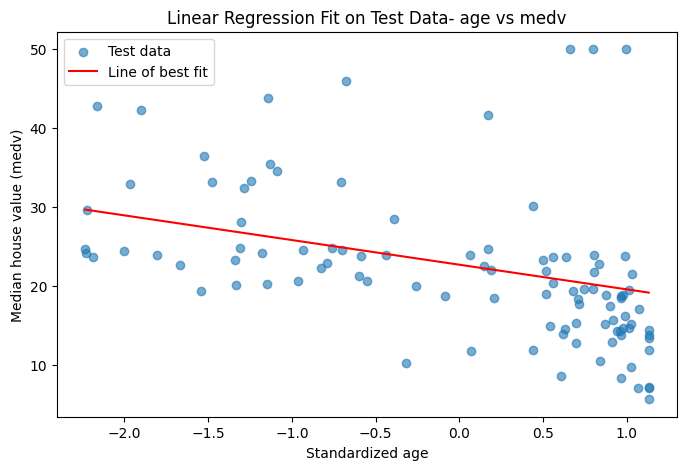

In [77]:

x_feature = x_test_scaled_age.flatten()
y_true = y_test.flatten()
x_sorted = np.sort(x_feature)
y_line = beta_0 + beta_1 * x_sorted

plt.figure(figsize=(8,5))
plt.scatter(x_feature, y_true, alpha=0.6, label="Test data")
plt.plot(x_sorted, y_line, color="red", label="Line of best fit")

plt.xlabel("Standardized age")
plt.ylabel("Median house value (medv)")
plt.title("Linear Regression Fit on Test Data- age vs medv")
plt.legend()
plt.show()

### 10. The models you have created thus far are only examples of single ordinary least squares. What if we want to include more than one independent variable in our prediction? Train a multiple linear regression model which incorporates all of the available independent variables in the data set. Using your model, predict the median house value. Compare your results on the training data set vs the test data set again. **(10 points)**

> Reminder: when comparing train vs test error, use **normalized SSE = (1/n)·∑(y-ŷ)^2**.


In [ ]:
# Modify your code for multiple linear regression (use all non-label columns available to train a model to predict median house value)
#Hint: remove the last column because we cannot use the dependent variable in the model

df.head()
x = df.iloc[:, :-1]
features = x.to_numpy()

np.random.seed(36)
indices = np.random.permutation(len(features))
train_size = int(0.8 * len(features))
train_idx, test_idx = indices[:train_size], indices[train_size:]
fx_train, fx_test = features[train_idx], features[test_idx]
fy_train, fy_test = y[train_idx], y[test_idx]

# standardizing

fx_mean = fx_train.mean(axis=0)
fx_std = fx_train.std(axis=0)
fx_train_scaled = (fx_train - fx_mean) / fx_std
fx_test_scaled = (fx_test - fx_mean) / fx_std
X_train_f = prepare_matrix(fx_train_scaled)
X_test_f = prepare_matrix(fx_test_scaled)

# our betas
beta_hat = np.linalg.inv(X_train_f.T @ X_train_f) @ X_train_f.T @ fy_train
print(beta_hat)

def predict(X, beta):
    return X @ beta

# applying

Y_train_pred = predict(X_train_f, beta_hat)
n = len(fy_train)
sse_train = (1/n) * np.sum((fy_train - Y_train_pred)**2)
print(sse_train)

Y_test_pred = predict(X_test_f, beta_hat)
n = len(fy_test)
sse_test = (1/n) * np.sum((fy_test - Y_test_pred)**2)
print(sse_test)
# for our model, we see that the normalized sse is greater for the test set than the train set

[22.66336634 -1.14233937  1.29614806 -0.14043168  0.92482796 -2.38457417
  2.09355089  0.45011761 -3.35792553  3.146052   -2.36884747 -1.89266656
 -4.3221266 ]
22.141488501712587
25.048650438007684


### 11. The model you made in the previous question only had linear terms of our features. Sometimes, we want to capture more complicated relationships between variables. To add more complexity to our model, experiment with differnet polynomial models. For each model, try to think about whether you may be overfitting or underfitting to the training data. Again, compare your performnance on the training data vs the testing data.


#### 11a. Modify the design matrix to include polynomial terms of degree 2. (Hint: add squared values of existing columns to the deign matrix X). Calculate the normalized SSE (SSE/n) on the training and testing data sets. **(10 points)**

> Reminder: use **SSE = (1/n)·∑(y-ŷ)^2** with n equal to the sample size for that split.


In [ ]:
### Modify for polynomial regression (degree 2)
# Reminder: when reporting SSE in this section, use **normalized SSE** = sum((y - yhat)^2) / n.
# TODO: build your degree-2 design matrix, fit coefficients, and compute train/test normalized SSE.

# seperate ivs
X = df.iloc[:, :-1].to_numpy()   # all features (using same model as 10, assuming this is the question)
y = df.iloc[:, -1].to_numpy()    # medv

# train test split
np.random.seed(36)
indices = np.random.permutation(len(X))
train_size = int(0.8 * len(X))

train_idx = indices[:train_size]
test_idx = indices[train_size:]

X_train = X[train_idx]
X_test = X[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]

# standardize 
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

X_train_scaled = (X_train - mean) / std
X_test_scaled = (X_test - mean) / std

# build  the new polynomial degree-2 design matrix
X_train_poly = np.column_stack([
    np.ones(len(X_train_scaled)), 
    X_train_scaled,
    X_train_scaled**2
])

X_test_poly = np.column_stack([
    np.ones(len(X_test_scaled)),
    X_test_scaled,
    X_test_scaled**2
])

# train model (OLS)
beta = np.linalg.inv(X_train_poly.T @ X_train_poly) @ X_train_poly.T @ y_train

# predictions
yhat_train = X_train_poly @ beta
yhat_test = X_test_poly @ beta

# normed sse
sse_train = np.sum((y_train - yhat_train)**2) / len(y_train)
sse_test = np.sum((y_test - yhat_test)**2) / len(y_test)

print("Degree 2 Polynomial Regression")
print("Normalized SSE (train)=", sse_train)
print("Normalized SSE (test)=", sse_test)

Degree 2 Polynomial Regression
Normalized SSE (train): 14.491613953445944
Normalized SSE (test): 23.739012920640135


#### 11aa. After fitting your degree-2 model, make a quick visualization for sanity-checking. **(5 points)**

Using the **same single feature** you used back in Q9 (your chosen independent variable (ours is 'age')), plot:
1. The original data points \((x, y)\) as a scatter plot.
2. The fitted quadratic curve \(\hat{y} = a + bx + cx^2\) on top of the scatter plot.

> Tip: sort the x-values before plotting the curve so the line looks smooth.



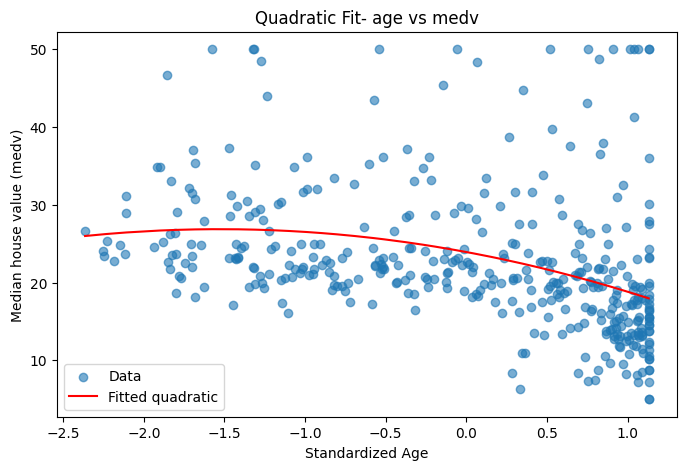

In [86]:
# 11aa: Plot datapoints and fitted quadratic yhat = a + b x + c x^2 (for your chosen feature from Q9)
# TODO: Fill in `x_feature`, `y_true`, and the coefficients a, b, c from your degree-2 fit.

# use the same feature from q9 (it was age)
x_feature = x_train_scaled_age.flatten()
y_true = y_train.flatten()

# build quadratic design matrix
X_quad = np.column_stack([
    np.ones_like(x_feature),
    x_feature,
    x_feature**2
])

# fit quadratic coeffs
beta_quad = np.linalg.inv(X_quad.T @ X_quad) @ X_quad.T @ y_true
a, b, c = beta_quad

# sort x values for smooth curve
x_sorted = np.sort(x_feature)
y_curve = a + b * x_sorted + c * x_sorted**2

# plotted!
plt.figure(figsize=(8,5))
plt.scatter(x_feature, y_true, alpha=0.6, label="Data")
plt.plot(x_sorted, y_curve, color="red", label="Fitted quadratic")

plt.xlabel("Standardized Age")
plt.ylabel("Median house value (medv)")
plt.title("Quadratic Fit- age vs medv")
plt.legend()
plt.show()

#### 11b. To test how our model performs as we change the degree of our model. Train models of degree 1 to degree 8. This will result in 8 different models.  For each model you create, save the Sum of Squared Errors (normalized SSE (SSE/n)) on the training and test data set respectively. We will use them for the next step to plot how they change as the model becomes more complex. **(20 points)**

> Reminder: use **SSE = (1/n)·∑(y-ŷ)^2** with n equal to the sample size for that split.

## NOTE - assuming asking for all features, visualized based on one but the few previous models were all features

In [103]:
### Fit polynomial models of degrees 1-8, save training and testing errors
# NOTE - still using 'crim' column (assuming still using one, never said otherwise)
# Reminder: store **normalized** SSE values for each split:
#   sse_k_train = sum((y_train - yhat_train)^2) / len(y_train)
#   sse_k_test  = sum((y_test  - yhat_test )^2) / len(y_test)
# TODO: implement loop over degrees below and save errors for plotting.

X = df.iloc[:, :-1].to_numpy()   
y = df.iloc[:, -1].to_numpy().reshape(-1, 1)

np.random.seed(36)
indices = np.random.permutation(len(X))
train_size = int(0.8 * len(X))
train_idx, test_idx = indices[:train_size], indices[train_size:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

mean, std = X_train.mean(axis=0), X_train.std(axis=0)
X_train_scaled = (X_train - mean) / std
X_test_scaled = (X_test - mean) / std

degrees = range(1, 9)
train_errors = []
test_errors = []

print(f"{'Degree':<10} | {'Train SSE':<15} | {'Test SSE':<15}")
print("-" * 45)

for d in degrees:
    X_train_poly = np.ones((len(X_train_scaled), 1))
    X_test_poly = np.ones((len(X_test_scaled), 1))
    
    for p in range(1, d + 1):
        X_train_poly = np.column_stack([X_train_poly, X_train_scaled**p])
        X_test_poly = np.column_stack([X_test_poly, X_test_scaled**p])

    A = X_train_poly.T @ X_train_poly
    b = X_train_poly.T @ y_train
    
    beta = np.linalg.solve(A + 1e-8 * np.eye(A.shape[0]), b)

    yhat_train = X_train_poly @ beta
    yhat_test = X_test_poly @ beta

    sse_train = np.mean((y_train - yhat_train)**2)
    sse_test = np.mean((y_test - yhat_test)**2)

    train_errors.append(sse_train)
    test_errors.append(sse_test)
    
    print(f"{d:<10} | {sse_train:<15.4f} | {sse_test:<15.4f}")

Degree     | Train SSE       | Test SSE       
---------------------------------------------
1          | 22.1415         | 25.0487        
2          | 13.4283         | 21.7518        
3          | 11.7499         | 25.9303        
4          | 10.8482         | 32.3145        
5          | 9.9701          | 80.7277        
6          | 8.4565          | 65.4599        
7          | 7.5244          | 1523.8352      
8          | 6.0543          | 34455.3789     


### Overfitting

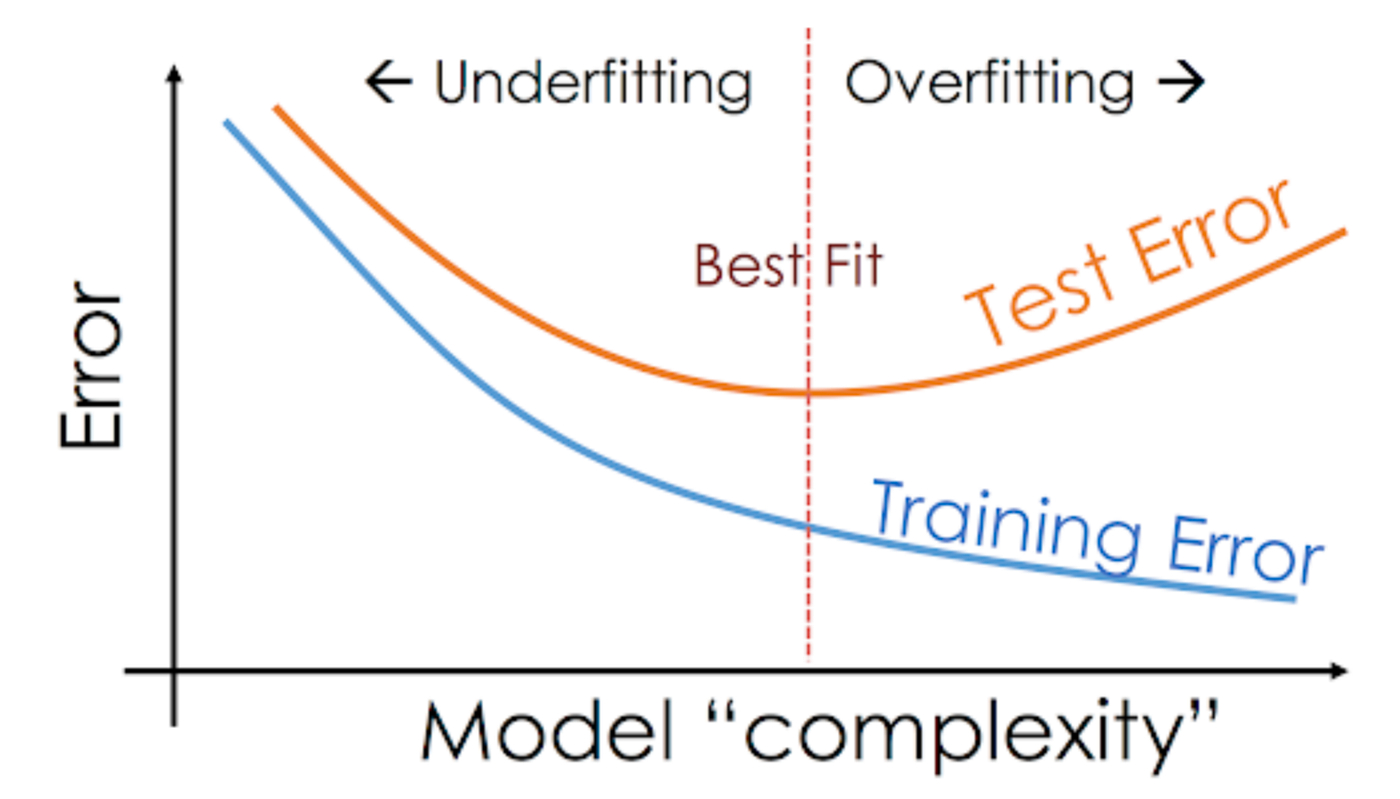

#### 11c. Using the training and testing normalized SSE (SSE/n) you calculated in the previous question, plot the errors for each model complexity. In this plot, the x-axis will be the model complexity (degree of the model) and the y-axis will be the normalized SSE (SSE/n) you calculated. What can you determine from this plot? How does the error on the training data set compare to the error on the testing data set as the degree of the model increases? **(10 points)**

> Reminder: use **SSE = (1/n)·∑(y-ŷ)^2** with n equal to the sample size for that split.



In [88]:
print(train_errors)
print(test_errors)

[np.float64(72.63820185057006), np.float64(71.55056380020713), np.float64(71.44923263365258), np.float64(71.31993783000668), np.float64(71.16559147514137), np.float64(71.15901312653664), np.float64(71.0633630595406), np.float64(71.03247840432073)]
[np.float64(72.09887527629324), np.float64(71.18063678508645), np.float64(70.8409950840476), np.float64(70.47739451437174), np.float64(71.181623482665), np.float64(71.28319583383305), np.float64(71.80255410105276), np.float64(72.2077389203488)]


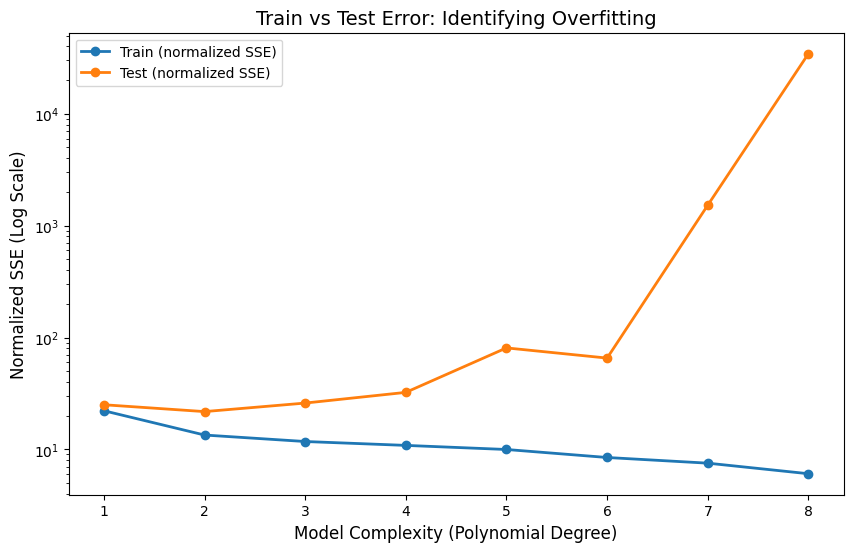

In [105]:
###Graph training and testing errors on same line plot to show overfitting
#After you correct SSE everywhere (use normalized SSE), make sure this plot renders and matches the reference image above.
#TODO: replace `degrees`, `train_errors`, `test_errors` with your actual arrays/lists.

plt.figure(figsize=(10, 6))

plt.plot(degrees, train_errors, marker='o', label="Train (normalized SSE)", linewidth=2)
plt.plot(degrees, test_errors, marker='o', label="Test (normalized SSE)", linewidth=2)
plt.yscale('log')
plt.xlabel("Model Complexity (Polynomial Degree)", fontsize=12)
plt.ylabel("Normalized SSE (Log Scale)", fontsize=12)
plt.title("Train vs Test Error: Identifying Overfitting", fontsize=14)
plt.legend()

plt.show()

### Answering the question

As the polynomial degree increases the training SSE decreases from 22.14 at degree 1 down to 6.05 at degree 8, which is expected, a more complex model will always fit the training data better. However, test SSE tells a very different story. It starts at 25.05 for degree 1, dips slightly at degree 2 (21.75), and then explodes dramatically, reaching 1,523 at degree 7 and 34,455 at degree 8.
This is a textbook example of overfitting. The model is not learning the true hidden relationship between age and house price and instead at higher degrees it is memorizing the noise in the training data. The gap between train SSE and test SSE widens more and more with each degree, which is the classic signature of high variance. Degree 2 appears to be the sweet spot here because it achieves a meaningful reduction in both train and test error compared to degree 1, without beginning to overfit. Beyond degree 2, the model becomes increasingly unstable and generalizes badly to unseen data.